# Required Libraries + Load in Data

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [4]:
#read the csv file
weather = pd.read_csv( "Weather 2019-2025/Weather 2019-2025.txt", sep= ',', skiprows= 46, header= 0 )

# Analyzing the Data

In [5]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   # STN     2557 non-null   int64
 1   YYYYMMDD  2557 non-null   int64
 2   DDVEC     2557 non-null   int64
 3   FHVEC     2557 non-null   int64
 4      FG     2557 non-null   int64
 5     FHX     2557 non-null   int64
 6    FHXH     2557 non-null   int64
 7     FHN     2557 non-null   int64
 8    FHNH     2557 non-null   int64
 9     FXX     2557 non-null   int64
 10   FXXH     2557 non-null   int64
 11     TG     2557 non-null   int64
 12     TN     2557 non-null   int64
 13    TNH     2557 non-null   int64
 14     TX     2557 non-null   int64
 15    TXH     2557 non-null   int64
 16   T10N     2557 non-null   int64
 17  T10NH     2557 non-null   int64
 18     SQ     2557 non-null   int64
 19     SP     2557 non-null   int64
 20      Q     2557 non-null   int64
 21     DR     2557 non-null   int64
 22     RH     2

In [6]:
weather.describe()

,# STN,YYYYMMDD,DDVEC,FHVEC,FG,FHX,FHXH,FHN,FHNH,FXX,...,VVN,VVNH,VVX,VVXH,UG,UX,UXH,UN,UNH,EV24
count,2557.0,2.557000e+03,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,260.0,2.022067e+07,190.808369,29.271412,33.369183,51.286664,10.910442,16.104810,8.427063,102.655456,...,39.729761,9.897927,78.020727,12.098944,79.021118,94.676965,9.556903,61.203363,13.448573,17.732499
std,0.0,2.000689e+04,90.926323,14.995639,13.845270,18.055588,5.397954,11.798449,8.547612,37.214587,...,24.693507,8.519387,7.072227,5.741769,10.765404,5.835016,8.899565,16.182888,4.024110,14.754101
min,260.0,2.019010e+07,1.000000,0.000000,7.000000,20.000000,1.000000,0.000000,1.000000,30.000000,...,0.000000,1.000000,15.000000,1.000000,37.000000,52.000000,1.000000,16.000000,1.000000,0.000000
25%,260.0,2.020100e+07,131.000000,18.000000,23.000000,40.000000,8.000000,10.000000,1.000000,80.000000,...,15.000000,3.000000,75.000000,10.000000,73.000000,93.000000,2.000000,49.000000,12.000000,5.000000
50%,260.0,2.022070e+07,206.000000,27.000000,31.000000,50.000000,11.000000,10.000000,4.000000,100.000000,...,49.000000,6.000000,81.000000,13.000000,80.000000,97.000000,5.000000,61.000000,14.000000,14.000000
75%,260.0,2.024040e+07,250.000000,38.000000,41.000000,60.000000,14.000000,20.000000,18.000000,120.000000,...,61.000000,19.000000,83.000000,16.000000,87.000000,98.000000,20.000000,74.000000,15.000000,28.000000
max,260.0,2.025123e+07,360.000000,94.000000,98.000000,150.000000,24.000000,70.000000,24.000000,310.000000,...,82.000000,24.000000,83.000000,24.000000,100.000000,100.000000,24.000000,98.000000,24.000000,59.000000


# Dealing with Missing Values

In [7]:
total = weather.isnull().sum().sort_values(ascending=False)
percent = (weather.isnull().sum()/weather.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
# STN,0,0.0
YYYYMMDD,0,0.0
DDVEC,0,0.0
FHVEC,0,0.0
FG,0,0.0
FHX,0,0.0
FHXH,0,0.0
FHN,0,0.0
FHNH,0,0.0
FXX,0,0.0


In [8]:
# Check for duplicates
weather.duplicated().sum()

np.int64(0)

# Univariate & Bivariate Analysis

## Univariate

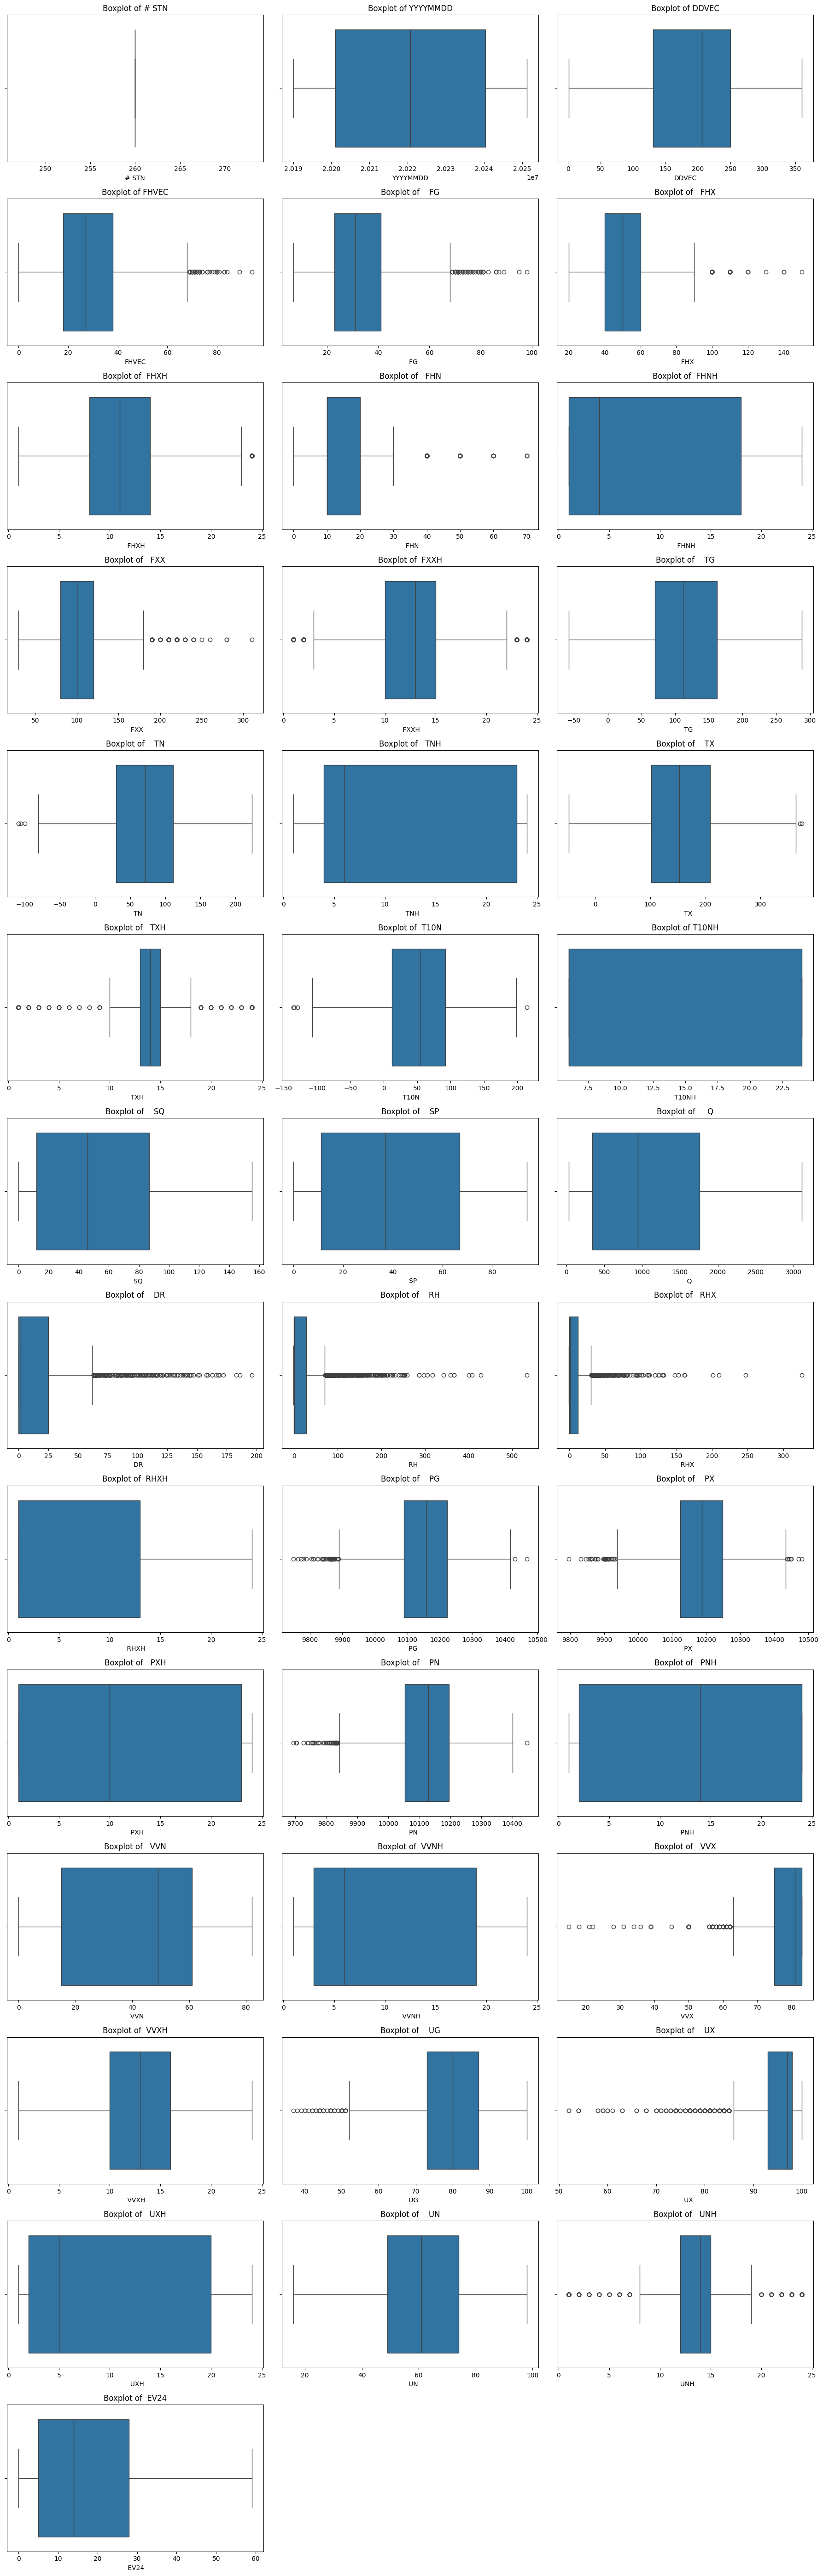

In [ ]:
#boxplot: for outliers and data spread
num_cols = weather.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=weather[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

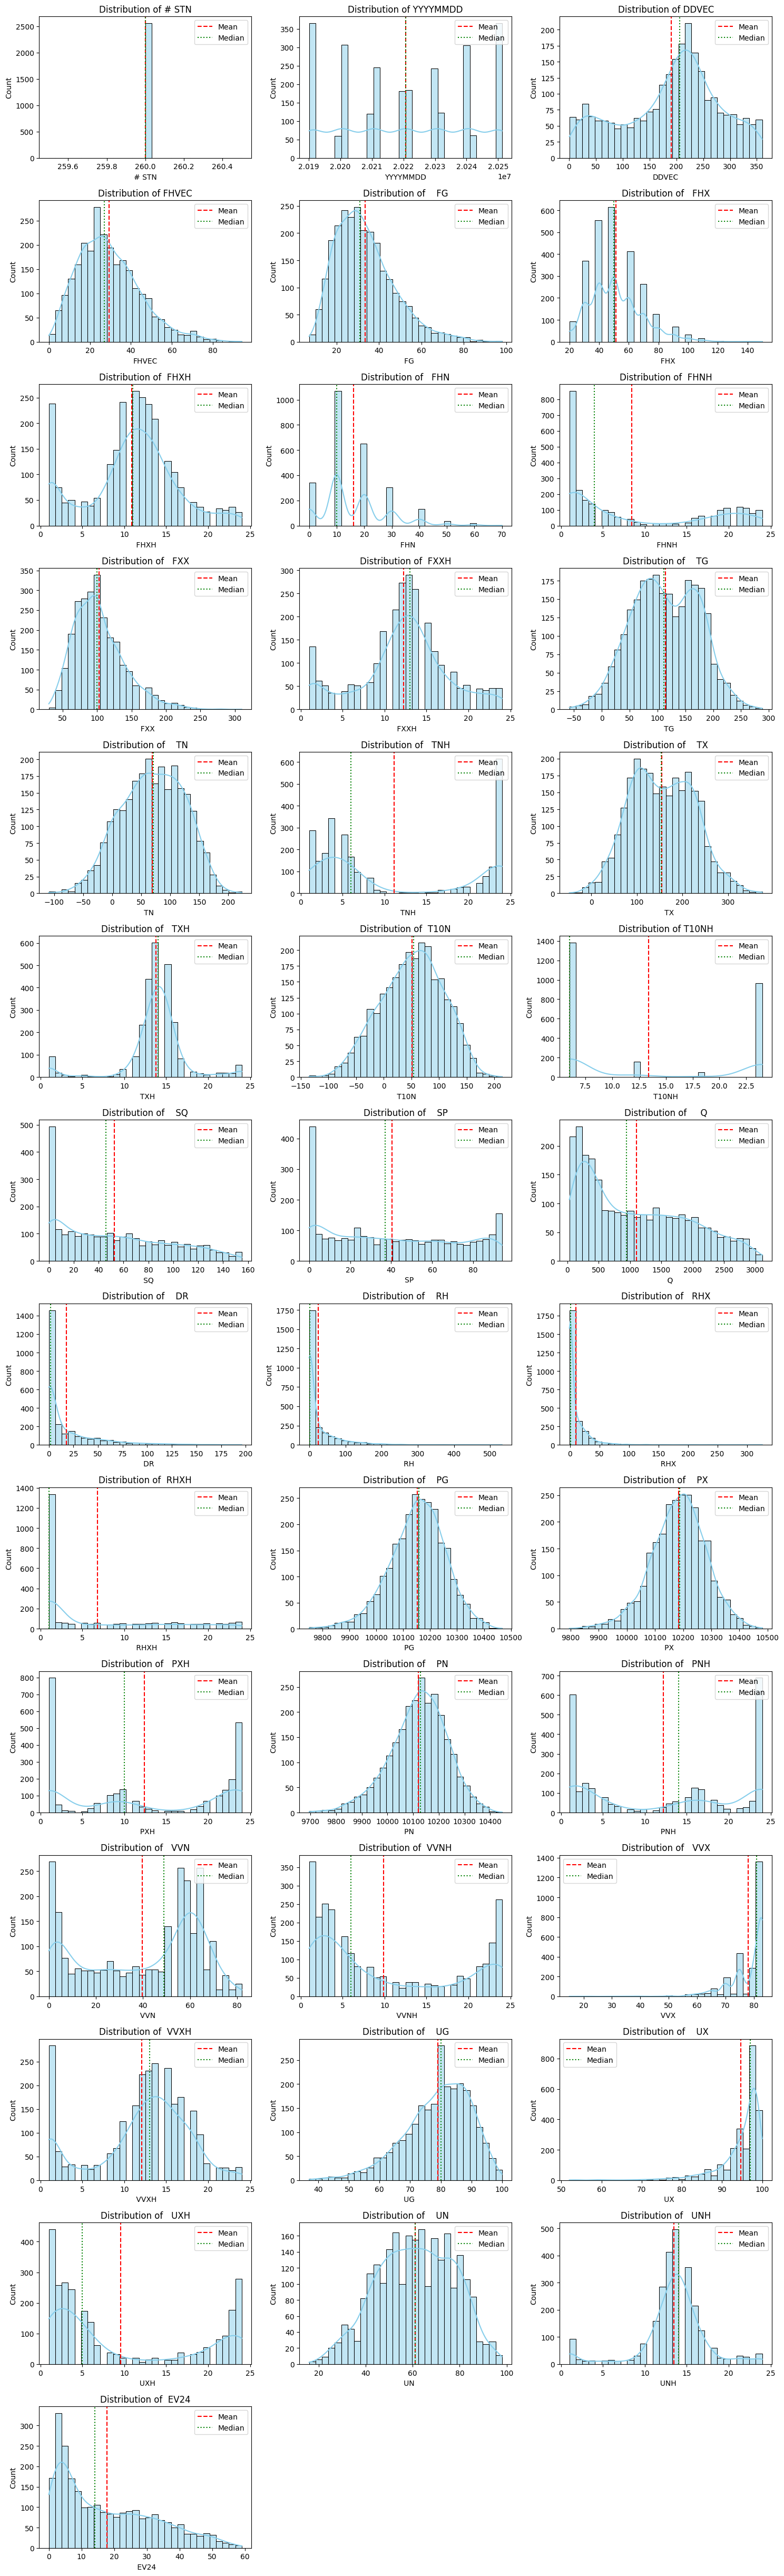

In [ ]:
#histogram: for distribution and central tendency (mean, median)
n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = weather[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color="skyblue")
    ax.axvline(data.mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(data.median(), color="green", linestyle=":", label="Median")
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Bivariate

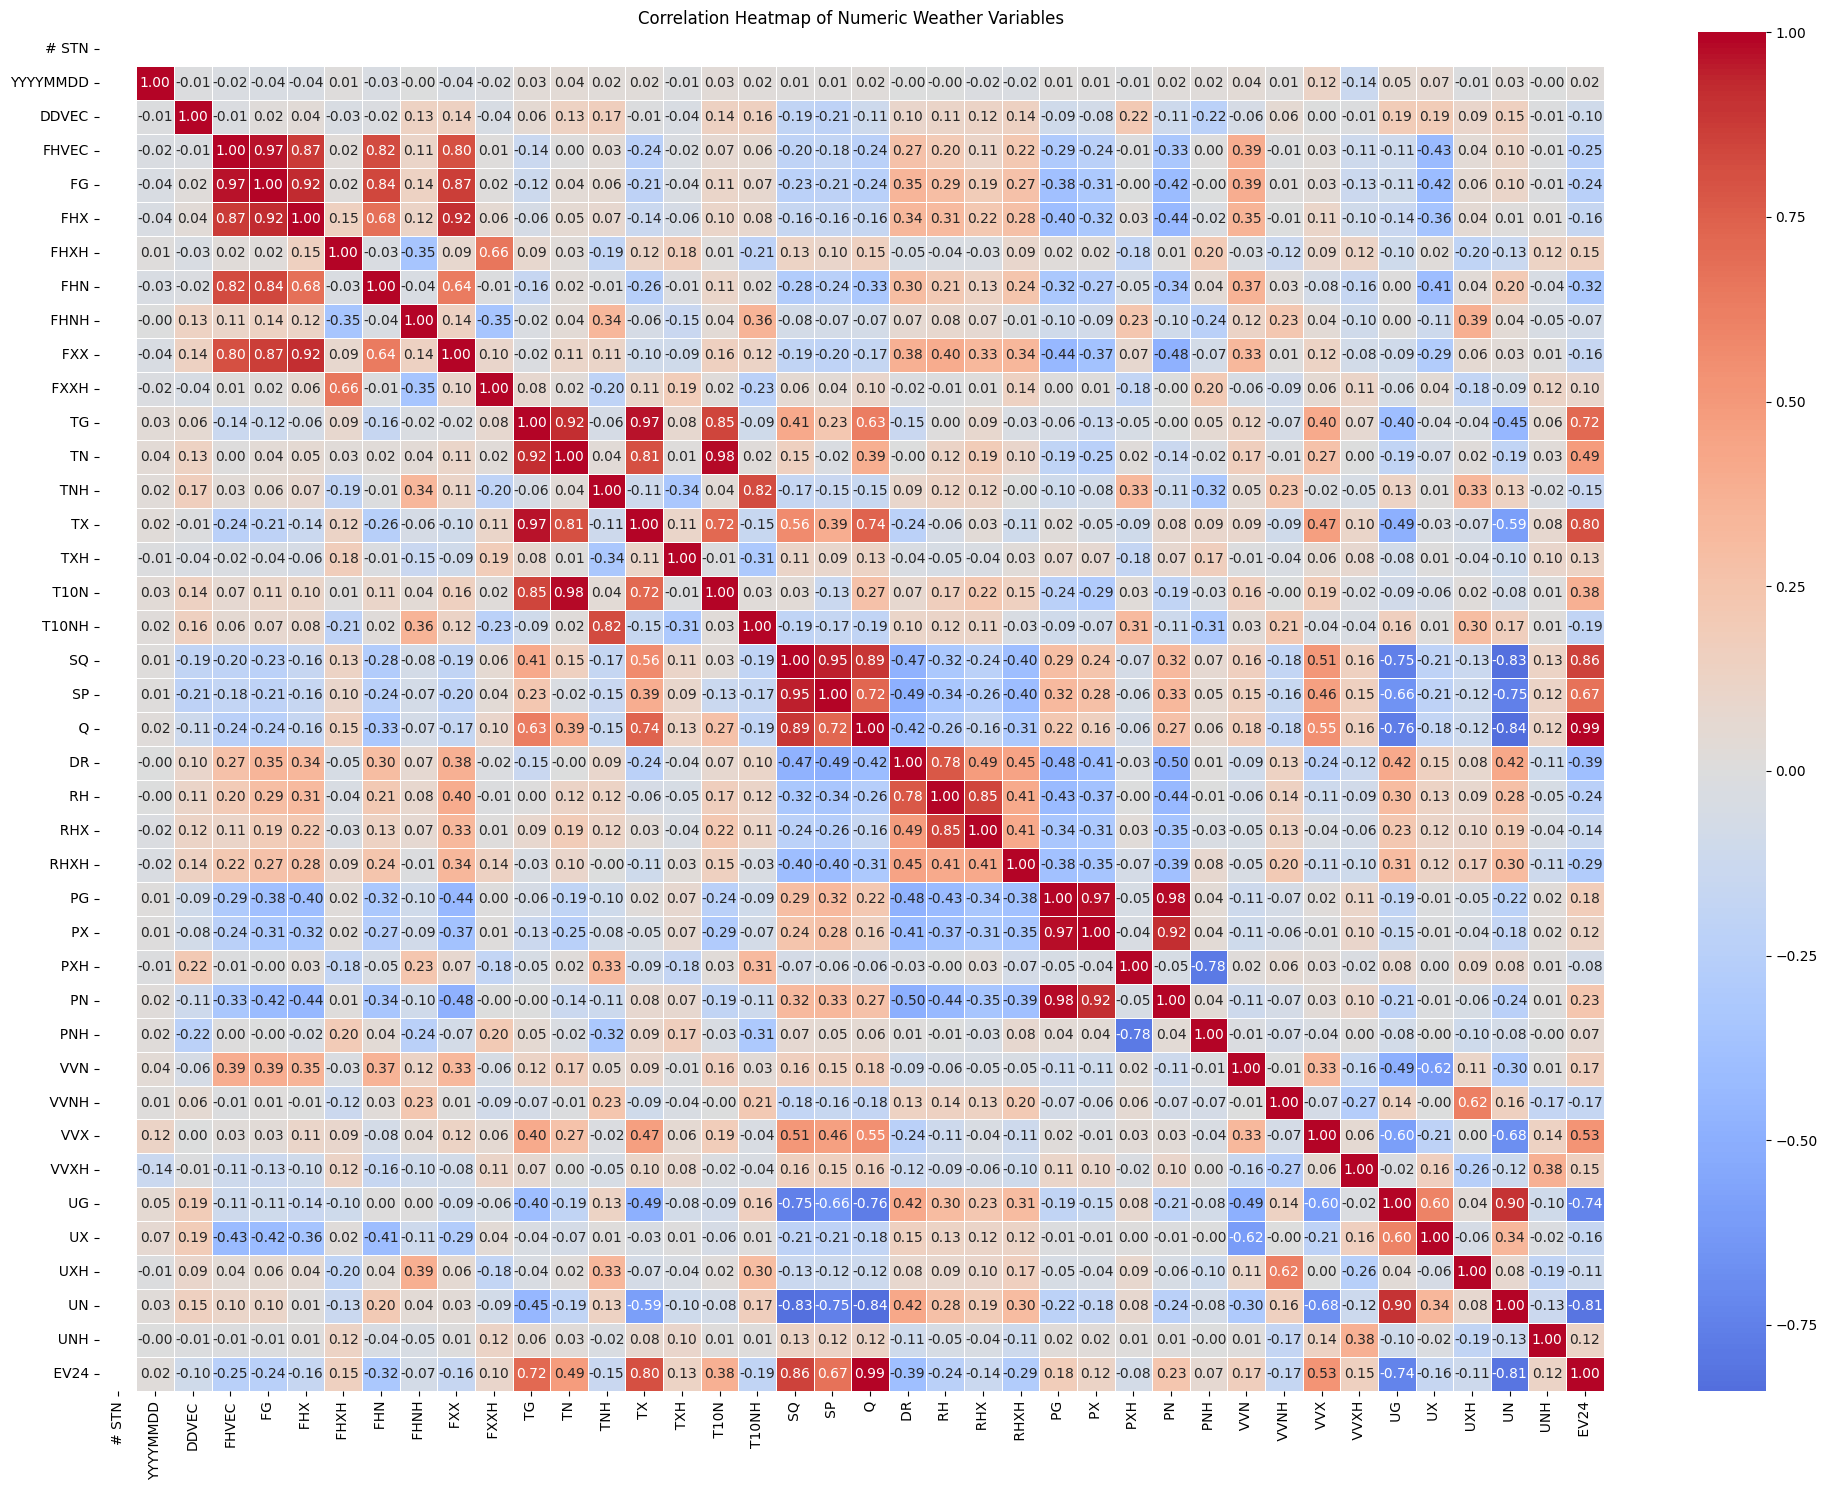

In [ ]:
#heatmap: for correlation between numeric variables
corr = weather[num_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Weather Variables")
plt.tight_layout()
plt.show()

In [40]:
#check the top 10 most correlated pairs of numeric variables
corr_abs = weather[num_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_pairs = upper.stack().sort_values(ascending=False).head(10)
print(top_pairs)

    Q  EV24    0.986972
   TN  T10N    0.980163
   PG    PN    0.978490
         PX    0.974933
   TG    TX    0.966511
FHVEC    FG    0.965609
   SQ    SP    0.948298
   FG   FHX    0.921756
   PX    PN    0.919462
   TG    TN    0.918034
dtype: float64


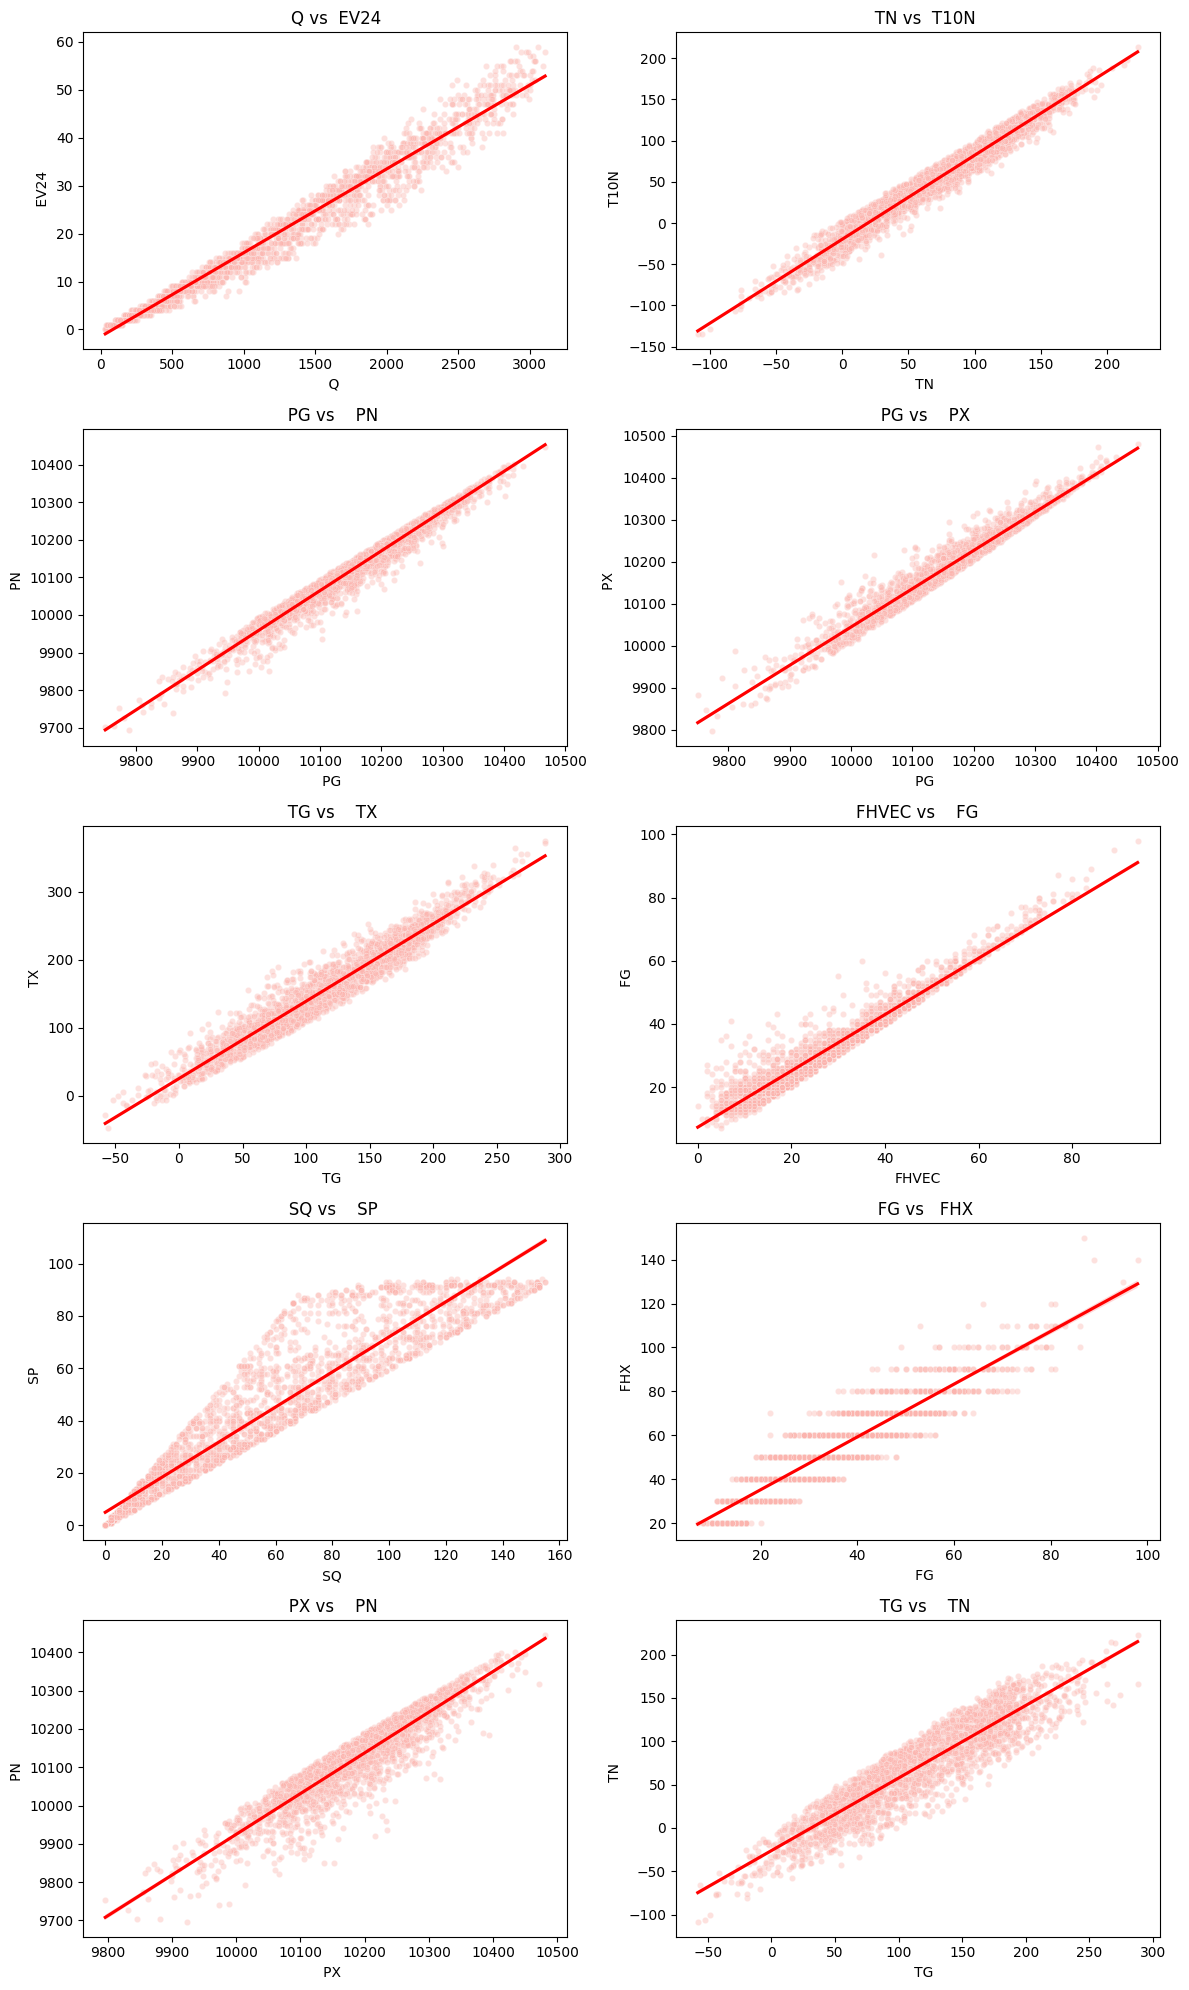

In [42]:
pairs = top_pairs.head(10).index.tolist()

n_pairs = len(pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=weather, x=x, y=y, alpha=0.4, s=20, ax=ax)
    sns.regplot(data=weather, x=x, y=y, scatter=False, color="red", ax=ax)
    ax.set_title(f"{x} vs {y}")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()